# FinanceBench EDA

Exploratory Data Analysis of the FinanceBench Open Source dataset.


## Dataset Description: FinanceBench

**FinanceBench** is a specialized benchmark dataset designed to evaluate the performance of Large Language Models (LLMs) on financial question answering tasks. It focuses on retrieving and reasoning over information contained in financial docments, primarily annual reports (10-Ks).

### Key Characteristics:
- **Domain**: Finance (Public Company Filings)
- **Source Documents**: 10-K Filings from various fiscal years.
- **Task**: Open-book Question Answering (Retrieval-Augmented Generation).

### Data Structure:
Based on the open-source subset analyzed, the dataset typically contains:
- **financebench_id**: Unique identifier for each question.
- **company**: The name of the company usually involved (e.g., 3M, Best Buy).
- **doc_name**: The specific source document (e.g., `3M_2018_10K`).
- **question**: The query posed to the model.
- **answer**: The ground truth answer.
- **evidence**: Text snippets from the document that support the answer.
- **question_type**: Categorization of the question logic (see below).
- **question_reasoning**: Detailed reasoning type (e.g., "Information extraction").

### Question Categories:
The benchmark includes diverse question types to test different capabilities:
1.  **metrics-generated**: Questions that ask for direct extraction of specific financial metrics or numbers from the documents.
2.  **domain-relevant**: Questions that require applying financial domain knowledge or logical reasoning to the extracted information.
3.  **novel-generated**: Questions involving hypotheticals, exclusions, or synthesized insights not directly present as a single line item.

### Purpose:
This dataset is essential for assessing how well LLMs can handle the specific lexicon, structure, and reasoning requirements of the financial domain, moving beyond general-purpose QA benchmarks.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

%matplotlib inline

## Load Data

In [3]:
file_path = '.result/financebench_open_source.jsonl'
try:
    df = pd.read_json(file_path, lines=True)
    print(f"Loaded {len(df)} records.")
except Exception as e:
    print(f"Error loading file: {e}")

Loaded 150 records.


In [4]:
df.head()

,financebench_id,company,doc_name,question_type,question_reasoning,domain_question_num,question,answer,justification,dataset_subset_label,evidence
0,financebench_id_03029,3M,3M_2018_10K,metrics-generated,Information extraction,None,What is the FY2018 capital expenditure amount ...,$1577.00,The metric capital expenditures was directly e...,OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...
1,financebench_id_04672,3M,3M_2018_10K,metrics-generated,Information extraction,None,Assume that you are a public equities analyst....,$8.70,"The metric ppne, net was directly extracted fr...",OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...
2,financebench_id_00499,3M,3M_2022_10K,domain-relevant,Logical reasoning (based on numerical reasoning),dg06,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...",CAPEX/Revenue\nFixed Assets/Total Assets\nROA=...,OPEN_SOURCE,[{'evidence_text': '3M Company and Subsidiarie...
3,financebench_id_01226,3M,3M_2022_10K,domain-relevant,Logical reasoning (based on numerical reasonin...,dg17,What drove operating margin change as of FY202...,Operating Margin for 3M in FY2022 has decrease...,None,OPEN_SOURCE,"[{'evidence_text': 'SG&A, measured as a percen..."
4,financebench_id_01865,3M,3M_2022_10K,novel-generated,None,None,"If we exclude the impact of M&A, which segment...",The consumer segment shrunk by 0.9% organically.,None,OPEN_SOURCE,[{'evidence_text': 'Worldwide Sales Change By...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   financebench_id       150 non-null    object
 1   company               150 non-null    object
 2   doc_name              150 non-null    object
 3   question_type         150 non-null    object
 4   question_reasoning    100 non-null    object
 5   domain_question_num   50 non-null     object
 6   question              150 non-null    object
 7   answer                150 non-null    object
 8   justification         100 non-null    object
 9   dataset_subset_label  150 non-null    object
 10  evidence              150 non-null    object
dtypes: object(11)
memory usage: 13.0+ KB


## Basic Statistics

In [6]:
df.describe(include='all')

,financebench_id,company,doc_name,question_type,question_reasoning,domain_question_num,question,answer,justification,dataset_subset_label,evidence
count,150,150,150,150,100,50,150,150,100,150,150
unique,150,32,84,3,9,25,150,149,94,1,144
top,financebench_id_03029,PepsiCo,BOEING_2022_10K,metrics-generated,Numerical reasoning,dg06,What is the FY2018 capital expenditure amount ...,There are none,The metric in question was calculated using ot...,OPEN_SOURCE,[{'evidence_text': 'We are very pleased with o...
freq,1,11,7,50,43,3,1,2,3,150,2


## Missing Values

In [7]:
df.isnull().sum()

financebench_id           0
company                   0
doc_name                  0
question_type             0
question_reasoning       50
domain_question_num     100
question                  0
answer                    0
justification            50
dataset_subset_label      0
evidence                  0
dtype: int64

## Distributions

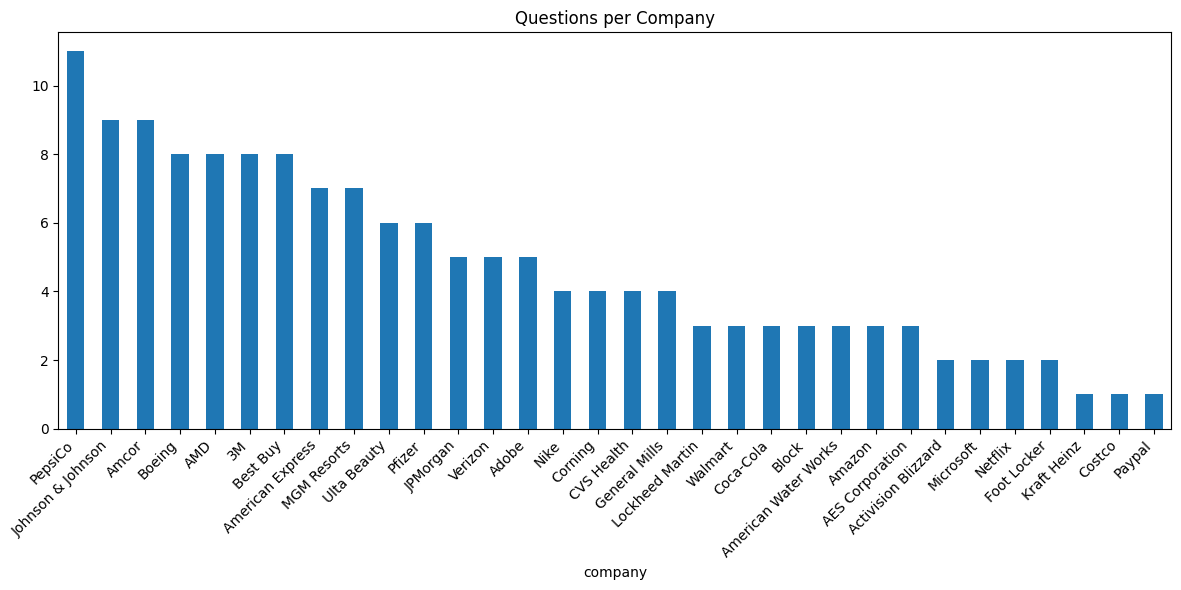

In [8]:
# Questions per Company
plt.figure(figsize=(12, 6))
df['company'].value_counts().plot(kind='bar')
plt.title('Questions per Company')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

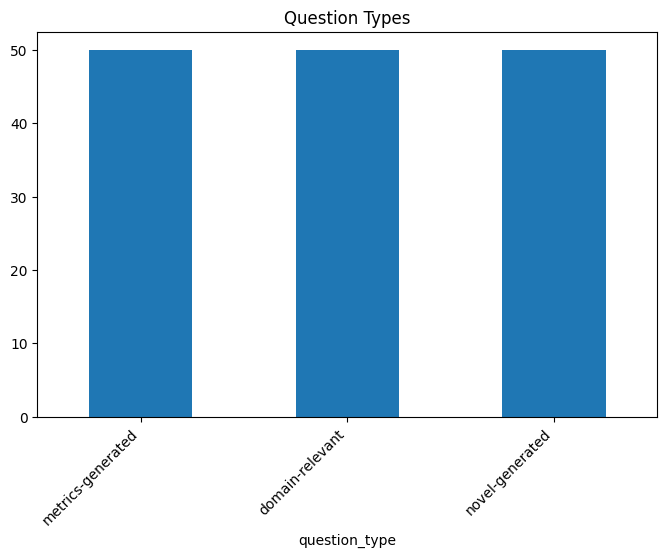

In [9]:
# Question Types
plt.figure(figsize=(8, 5))
df['question_type'].value_counts().plot(kind='bar')
plt.title('Question Types')
plt.xticks(rotation=45, ha='right')
plt.show()

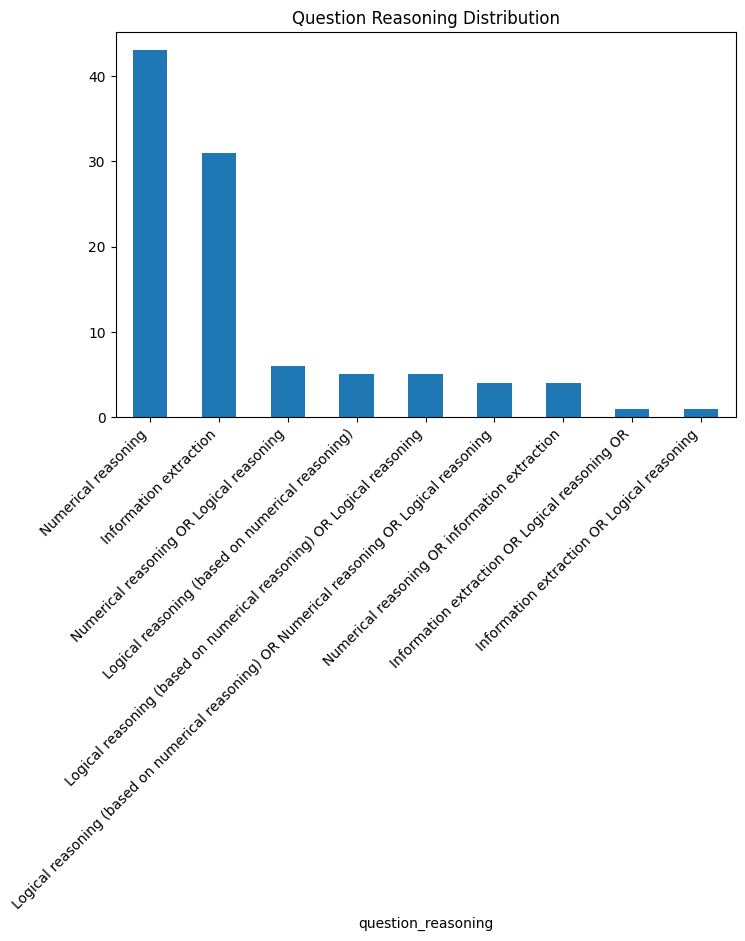

In [12]:
# Question Types
plt.figure(figsize=(8, 5))
df['question_reasoning'].value_counts().plot(kind='bar')
plt.title('Question Reasoning Distribution')
plt.xticks(rotation=45, ha='right')
plt.show()

## Text Analysis

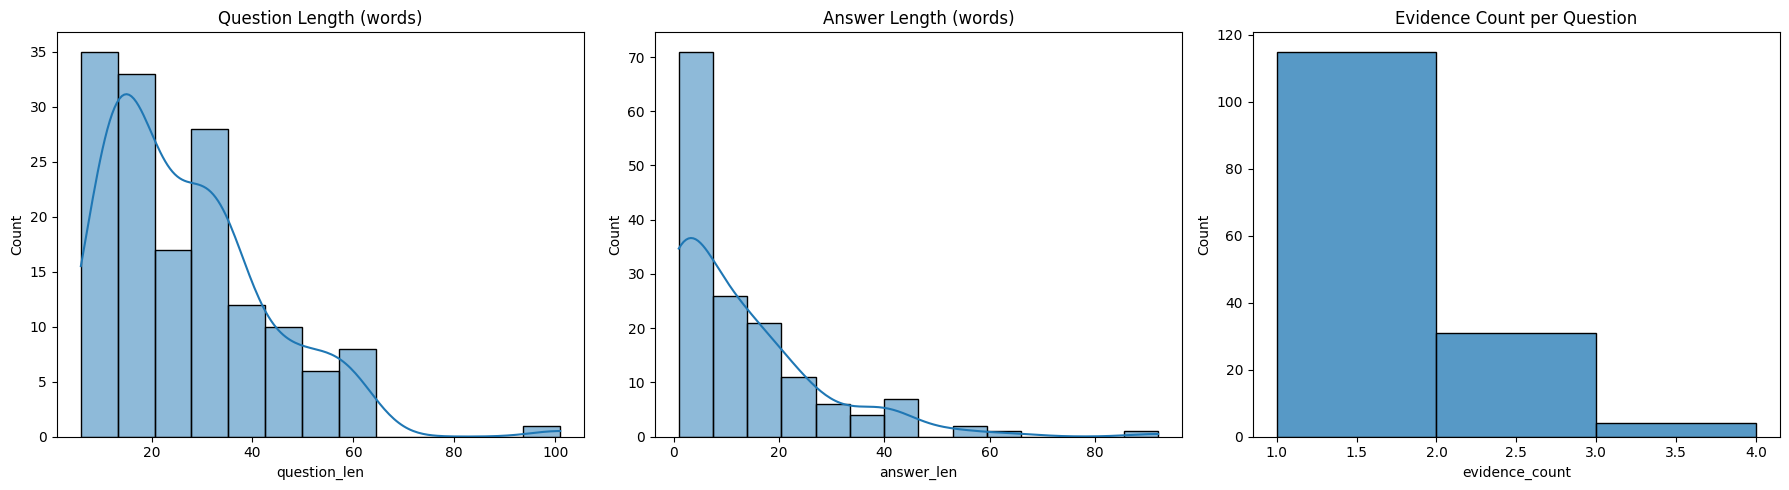

In [10]:
df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))
df['answer_len'] = df['answer'].apply(lambda x: len(str(x).split()))
df['evidence_count'] = df['evidence'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['question_len'], ax=axes[0], kde=True)
axes[0].set_title('Question Length (words)')

sns.histplot(df['answer_len'], ax=axes[1], kde=True)
axes[1].set_title('Answer Length (words)')

sns.histplot(df['evidence_count'], ax=axes[2], kde=False, bins=range(1, df['evidence_count'].max()+2))
axes[2].set_title('Evidence Count per Question')

plt.tight_layout()
plt.show()

## Evidence Inspection

In [11]:
# Look at the first evidence of the first question to understand structure
if 'evidence' in df.columns and len(df) > 0:
    sample_evidence = df.iloc[0]['evidence']
    print(json.dumps(sample_evidence, indent=2))

[
  {
    "evidence_text": "Table of Contents \n3M Company and Subsidiaries\nConsolidated Statement of Cash Flow s\nYears ended December 31\n \n(Millions)\n \n2018\n \n2017\n \n2016\n \nCash Flows from Operating Activities\n \n \n \n \n \n \n \nNet income including noncontrolling interest\n \n$\n5,363 \n$\n4,869 \n$\n5,058 \nAdjustments to reconcile net income including noncontrolling interest to net cash\nprovided by operating activities\n \n \n \n \n \n \n \nDepreciation and amortization\n \n \n1,488 \n \n1,544 \n \n1,474 \nCompany pension and postretirement contributions\n \n \n(370) \n \n(967) \n \n(383) \nCompany pension and postretirement expense\n \n \n410 \n \n334 \n \n250 \nStock-based compensation expense\n \n \n302 \n \n324 \n \n298 \nGain on sale of businesses\n \n \n(545) \n \n(586) \n \n(111) \nDeferred income taxes\n \n \n(57) \n \n107 \n \n 7 \nChanges in assets and liabilities\n \n \n \n \n \n \n \nAccounts receivable\n \n \n(305) \n \n(245) \n \n(313) \nInventories\n 

## Test Run Analysis: GPT-oss20B

Analysis of the end-to-end test run results for GPT-oss20B.

In [13]:
test_run_path = '.result/end_to_end_test_run_GPT-oss20B.csv'
try:
    df_test = pd.read_csv(test_run_path)
    print(f"Loaded test run data with {len(df_test)} records.")
except Exception as e:
    print(f"Error loading file: {e}")

Loaded test run data with 120 records.


In [14]:
df_test.head()

,Name,Input,Actual Output,Expected Output,Status,Context,Retrieval Context,Tools Called,Expected Tools,Comments,...,Faithfulness Error,Faithfulness Strict Mode,Faithfulness Evaluation Model,Hallucination Score,Hallucination Reason,Hallucination Threshold,Hallucination Success,Hallucination Error,Hallucination Strict Mode,Hallucination Evaluation Model
0,test_case_0,What is the FY2018 capital expenditure amount ...,The provided context does not contain any fina...,$1577.00,Passed,Error performing vector similarity search: Fai...,Error performing vector similarity search: Fai...,NaN,NaN,NaN,...,NaN,False,gpt-5-mini,NaN,The score is 0.00 because the actual output ma...,0.5,True,NaN,False,gpt-5-mini
1,test_case_1,Assume that you are a public equities analyst....,"$8.74 billion (Net Property, Plant & Equipment...",$8.70,Failed,**Consolidated Balance Sheet** (FinancialState...,**Consolidated Balance Sheet** (FinancialState...,NaN,NaN,NaN,...,NaN,False,gpt-5-mini,0.666667,The score is 0.67 because the actual output co...,0.5,False,NaN,False,gpt-5-mini
2,test_case_2,Is 3M a capital-intensive business based on FY...,"**Answer:** \nBased on FY 2022 data, 3M is **...","No, the company is managing its CAPEX and Fixe...",Passed,**RESULTS OF OPERATIONS** (FinancialStatement)...,**RESULTS OF OPERATIONS** (FinancialStatement)...,NaN,NaN,NaN,...,NaN,False,gpt-5-mini,NaN,The score is 0.00 because all statements in th...,0.5,True,NaN,False,gpt-5-mini
3,test_case_3,What drove operating margin change as of FY202...,**Operating‑margin change (FY 2022)** \n- 202...,Operating Margin for 3M in FY2022 has decrease...,Failed,**RESULTS OF OPERATIONS** (FinancialStatement)...,**RESULTS OF OPERATIONS** (FinancialStatement)...,NaN,NaN,NaN,...,NaN,False,gpt-5-mini,0.666667,The score is 0.67 because the output largely m...,0.5,False,NaN,False,gpt-5-mini
4,test_case_4,"If we exclude the impact of M&A, which segment...",The provided contexts do not contain any finan...,The consumer segment shrunk by 0.9% organically.,Passed,**Healthcare Industry** (Industry) [similarity...,**Healthcare Industry** (Industry) [similarity...,NaN,NaN,NaN,...,NaN,False,gpt-5-mini,NaN,The score is 0.00 because all provided context...,0.5,True,NaN,False,gpt-5-mini


### Status Distribution

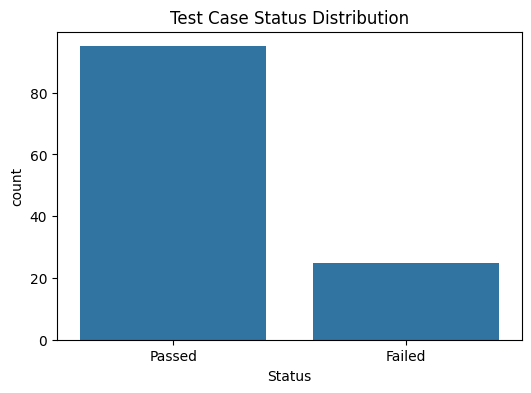

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df_test)
plt.title('Test Case Status Distribution')
plt.show()

### Faithfulness & Hallucination Scores

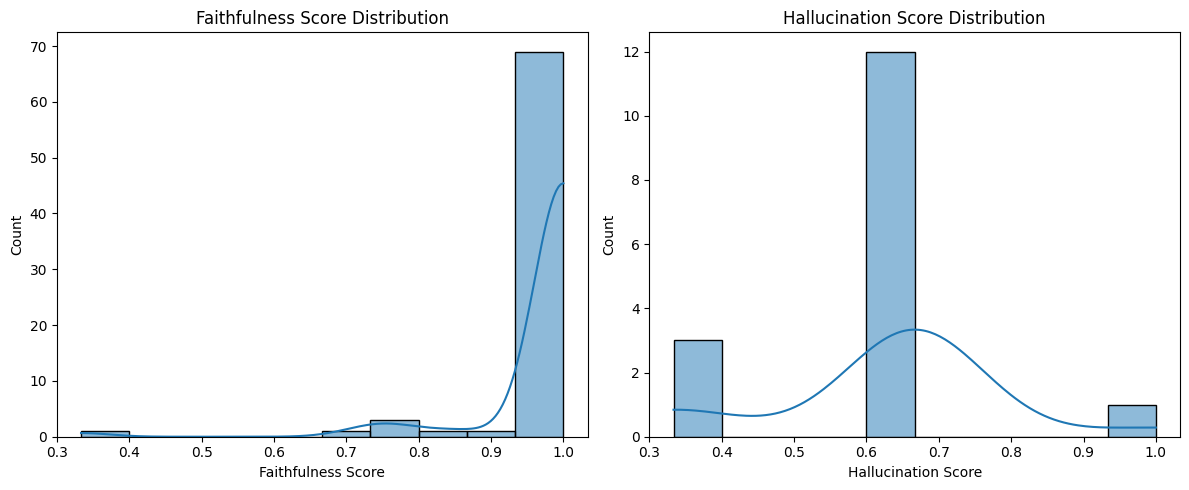

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_test['Faithfulness Score'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Faithfulness Score Distribution')

sns.histplot(df_test['Hallucination Score'], bins=10, kde=True, ax=axes[1])
axes[1].set_title('Hallucination Score Distribution')

plt.tight_layout()
plt.show()

### Run Duration

Average Run Duration: 84.77 seconds


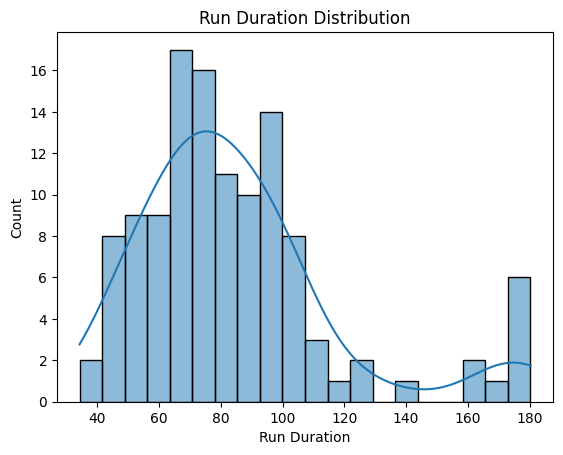

In [17]:
print(f"Average Run Duration: {df_test['Run Duration'].mean():.2f} seconds")
sns.histplot(df_test['Run Duration'], bins=20, kde=True)
plt.title('Run Duration Distribution')
plt.show()

## Failure Analysis by Question Category

Merging test results with the original dataset to analyze failure rates by question type and reasoning.

In [19]:
source_path = '.result/financebench_open_source.jsonl'
try:
    df_source = pd.read_json(source_path, lines=True)
    print(f"Loaded source data with {len(df_source)} records.")
except Exception as e:
    print(f"Error loading source file: {e}")

Loaded source data with 150 records.


In [20]:
# Merge on question text
df_merged = pd.merge(df_test, df_source, left_on='Input', right_on='question', how='left')
print(f"Merged data shape: {df_merged.shape}")
df_merged[['Input', 'question', 'question_type', 'question_reasoning', 'Status']].head()

Merged data shape: (120, 37)


,Input,question,question_type,question_reasoning,Status
0,What is the FY2018 capital expenditure amount ...,What is the FY2018 capital expenditure amount ...,metrics-generated,Information extraction,Passed
1,Assume that you are a public equities analyst....,Assume that you are a public equities analyst....,metrics-generated,Information extraction,Failed
2,Is 3M a capital-intensive business based on FY...,Is 3M a capital-intensive business based on FY...,domain-relevant,Logical reasoning (based on numerical reasoning),Passed
3,What drove operating margin change as of FY202...,What drove operating margin change as of FY202...,domain-relevant,Logical reasoning (based on numerical reasonin...,Failed
4,"If we exclude the impact of M&A, which segment...","If we exclude the impact of M&A, which segment...",novel-generated,None,Passed


In [31]:
rows_to_drop = [1, 20, 21, 38, 39, 49, 58, 115, 119]
df_merged.drop(rows_to_drop, inplace=True)

### Pass/Fail by Question Type

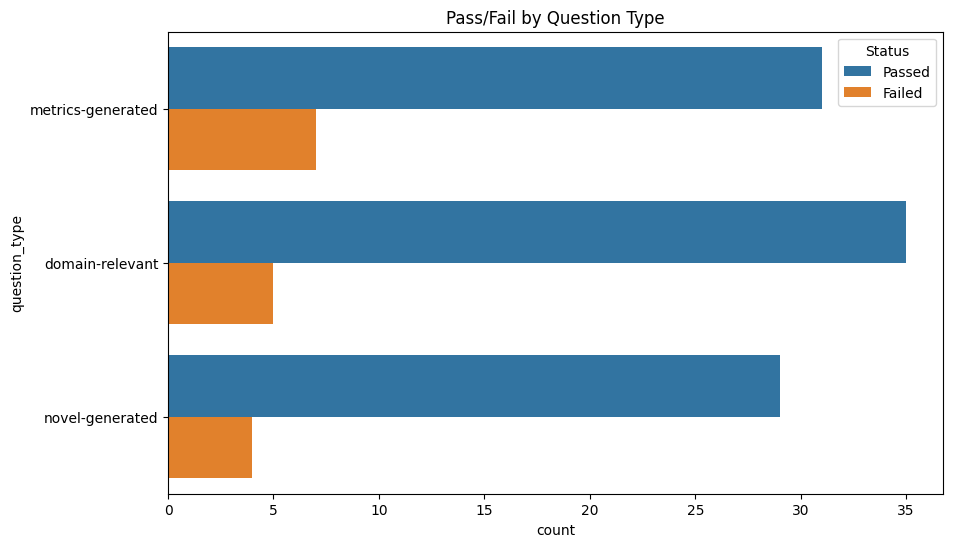

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(y='question_type', hue='Status', data=df_merged)
plt.title('Pass/Fail by Question Type')
plt.show()

In [33]:
# Calculate pass rate by question type
pass_rates_type = df_merged.groupby('question_type')['Status'].apply(lambda x: (x == 'Passed').mean()).sort_values()
print("Pass Rate by Question Type:")
print(pass_rates_type)

Pass Rate by Question Type:
question_type
metrics-generated    0.815789
domain-relevant      0.875000
novel-generated      0.878788
Name: Status, dtype: float64


### Pass/Fail by Question Reasoning

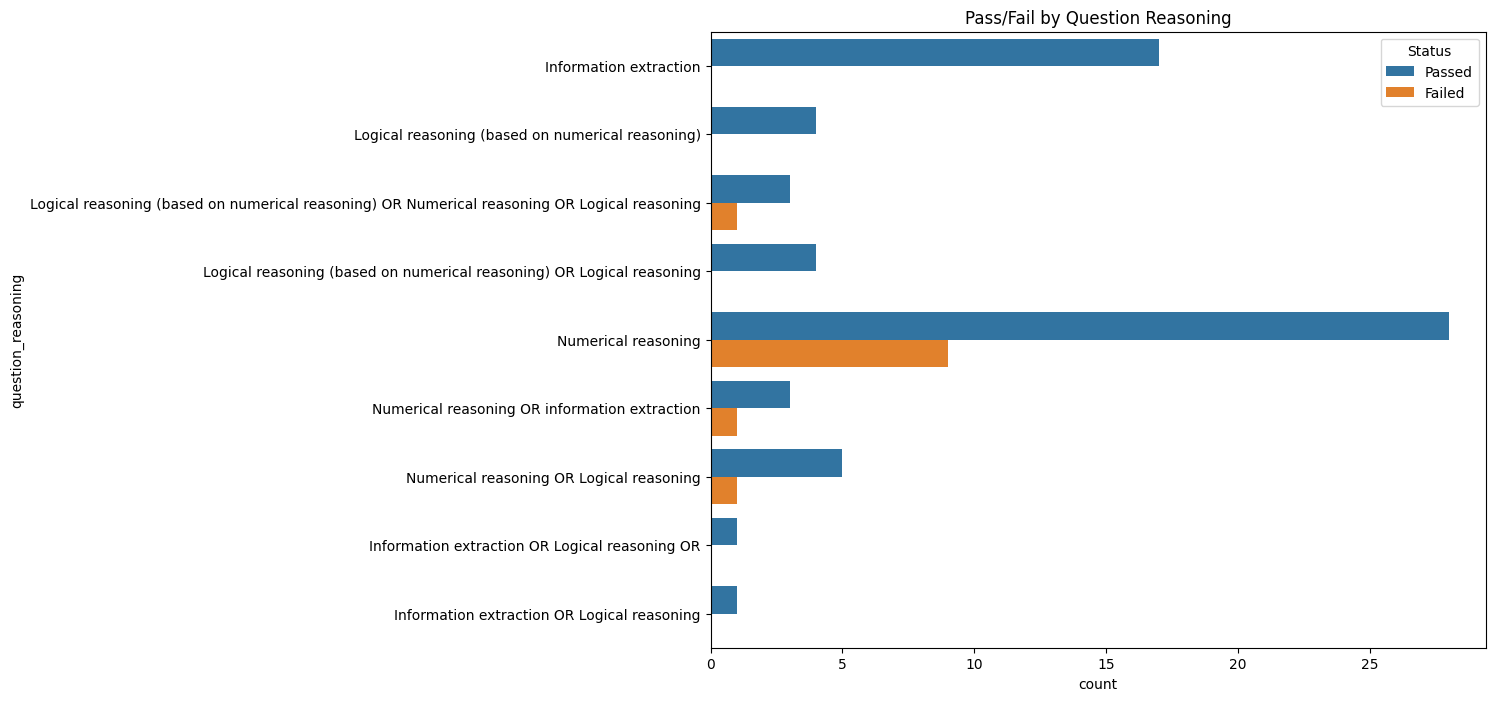

In [34]:
plt.figure(figsize=(10, 8))
sns.countplot(y='question_reasoning', hue='Status', data=df_merged)
plt.title('Pass/Fail by Question Reasoning')
plt.show()

In [24]:
# Calculate pass rate by question reasoning
pass_rates_reasoning = df_merged.groupby('question_reasoning')['Status'].apply(lambda x: (x == 'Passed').mean()).sort_values()
print("Pass Rate by Question Reasoning:")
print(pass_rates_reasoning)

Pass Rate by Question Reasoning:
question_reasoning
Information extraction                                                                          0.653846
Logical reasoning (based on numerical reasoning) OR Numerical reasoning OR Logical reasoning    0.750000
Numerical reasoning OR information extraction                                                   0.750000
Numerical reasoning                                                                             0.756757
Numerical reasoning OR Logical reasoning                                                        0.833333
Information extraction OR Logical reasoning                                                     1.000000
Information extraction OR Logical reasoning OR                                                  1.000000
Logical reasoning (based on numerical reasoning)                                                1.000000
Logical reasoning (based on numerical reasoning) OR Logical reasoning                           1.000000
Nam

## Deep Dive: Faithfulness & Hallucination Scores

Detailed analysis of how Faithfulness and Hallucination scores correlate with test status and question categories.

### Scores vs Test Status

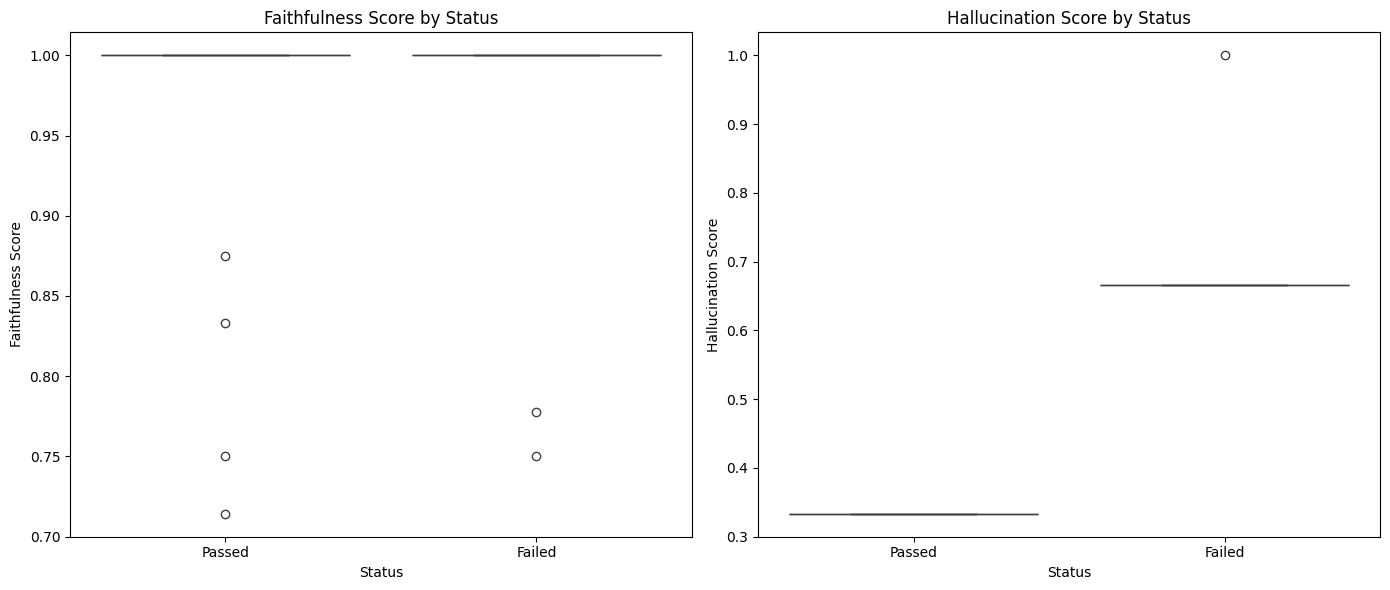

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Status', y='Faithfulness Score', data=df_merged, ax=axes[0])
axes[0].set_title('Faithfulness Score by Status')

sns.boxplot(x='Status', y='Hallucination Score', data=df_merged, ax=axes[1])
axes[1].set_title('Hallucination Score by Status')

plt.tight_layout()
plt.show()

### Scores by Question Type

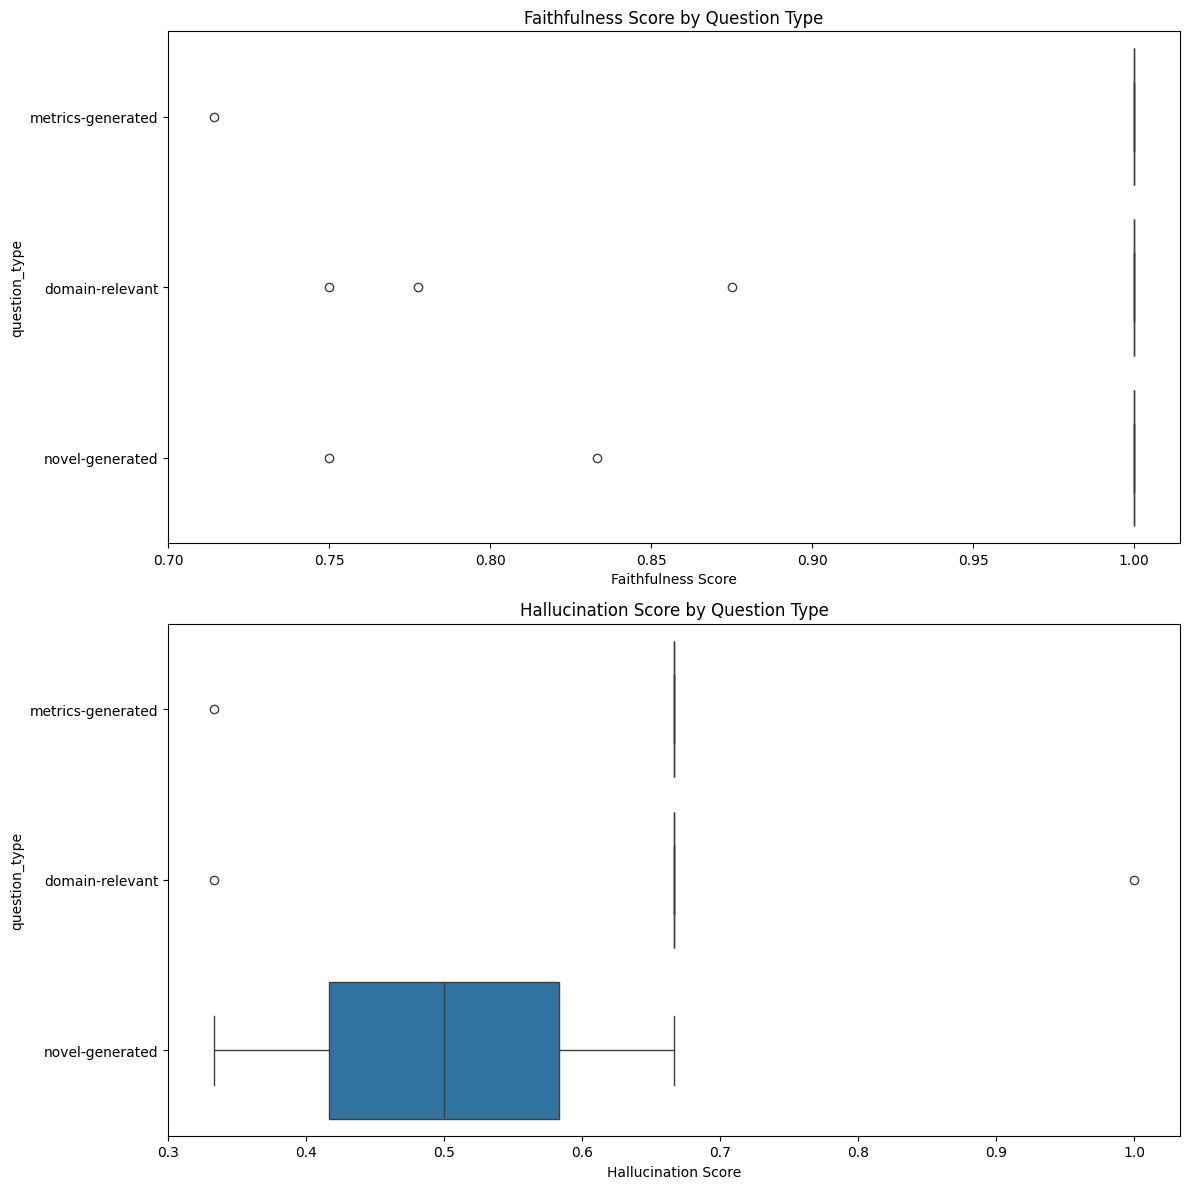

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(x='Faithfulness Score', y='question_type', data=df_merged, ax=axes[0])
axes[0].set_title('Faithfulness Score by Question Type')

sns.boxplot(x='Hallucination Score', y='question_type', data=df_merged, ax=axes[1])
axes[1].set_title('Hallucination Score by Question Type')

plt.tight_layout()
plt.show()

In [41]:
df_merged['Faithfulness Score'].describe()

count    71.000000
mean      0.981696
std       0.062750
min       0.714286
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: Faithfulness Score, dtype: float64

### Scores by Question Reasoning

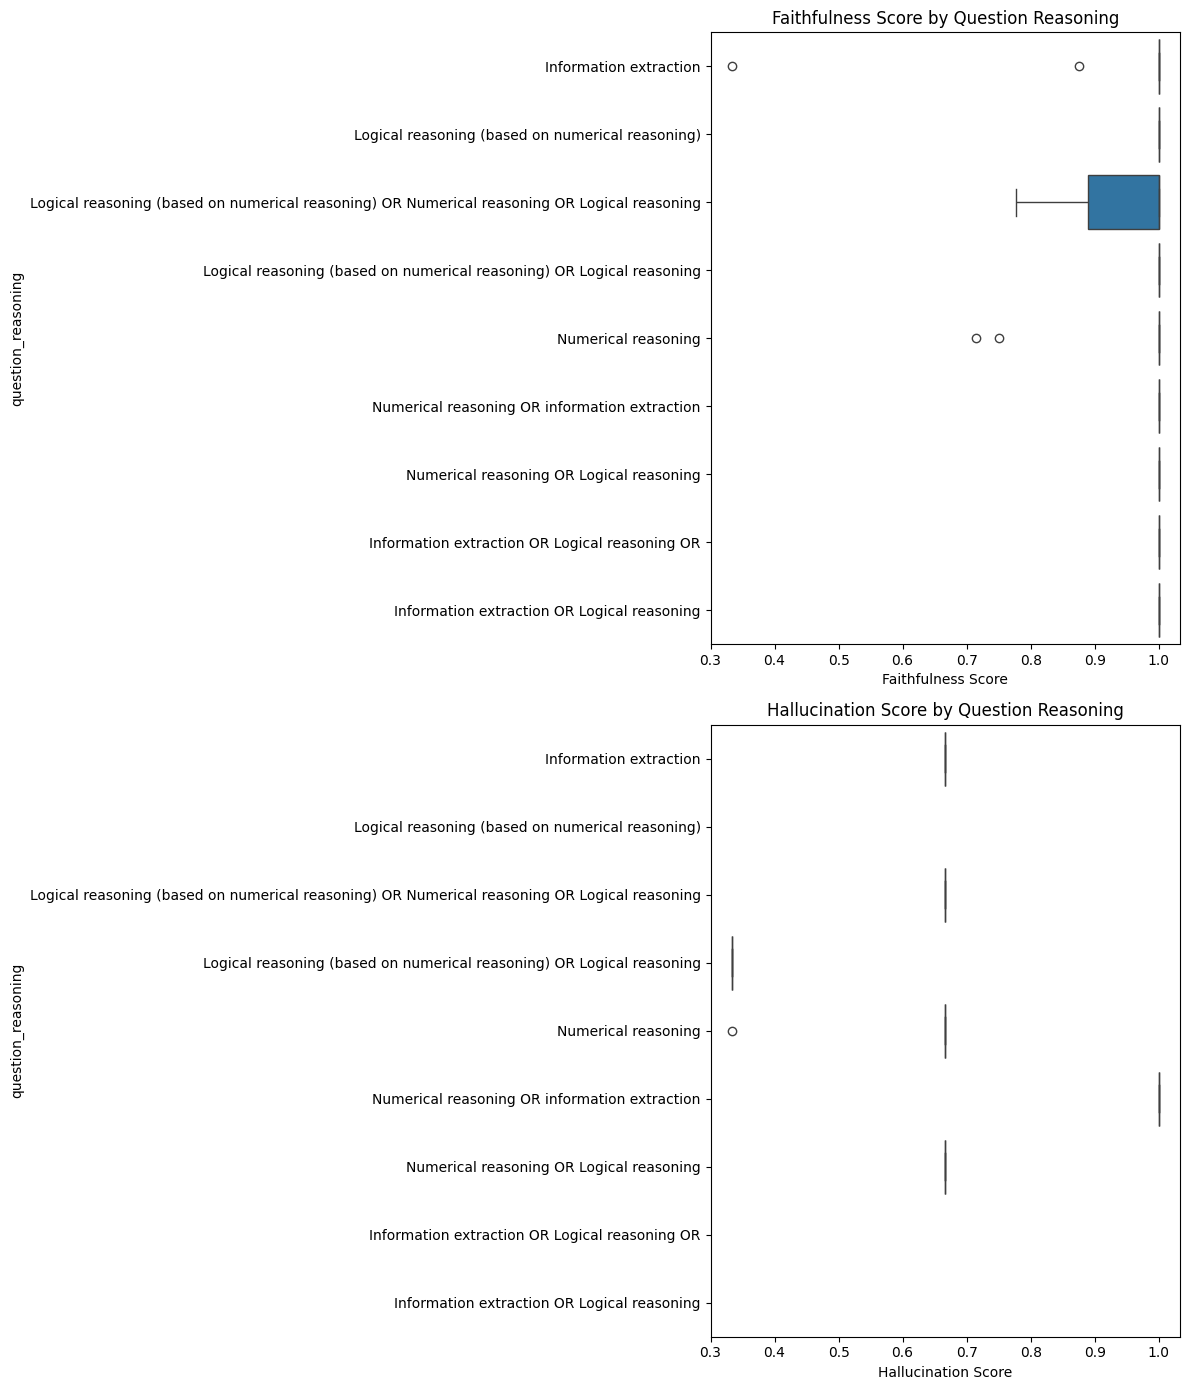

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

sns.boxplot(x='Faithfulness Score', y='question_reasoning', data=df_merged, ax=axes[0])
axes[0].set_title('Faithfulness Score by Question Reasoning')

sns.boxplot(x='Hallucination Score', y='question_reasoning', data=df_merged, ax=axes[1])
axes[1].set_title('Hallucination Score by Question Reasoning')

plt.tight_layout()
plt.show()

### Faithfulness vs Hallucination Correlation

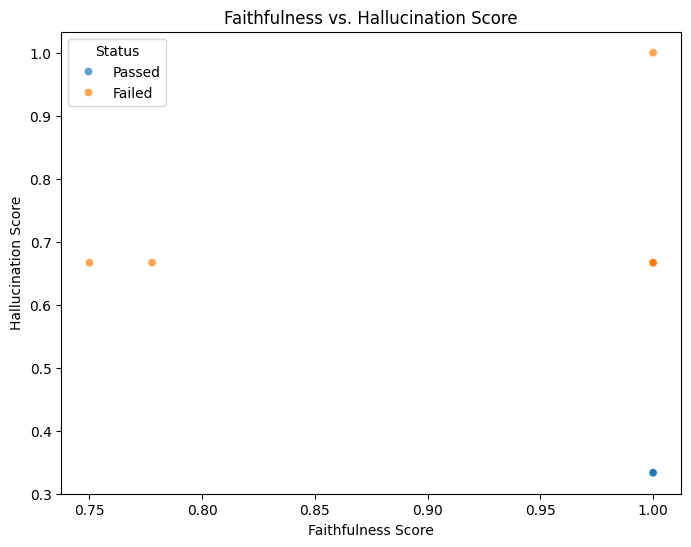

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Faithfulness Score', y='Hallucination Score', hue='Status', data=df_merged, alpha=0.7)
plt.title('Faithfulness vs. Hallucination Score')
plt.show()

## Deep Dive: Information Extraction Failures

Inspecting specific failure cases for 'Information extraction' questions to understand retrieval and reasoning issues.

In [51]:
# Filter for Information extraction failures
info_extraction_failures = df_merged[
    (df_merged['question_reasoning'] == 'Numerical reasoning') &
    (df_merged['Status'] != 'Passed')
]

print(f"Found {len(info_extraction_failures)} failed 'Information extraction' cases.")


Found 9 failed 'Information extraction' cases.


In [52]:
# Display details for each failure
for index, row in info_extraction_failures.iterrows():
    print(f"--- Case {index} ---")
    print(f"Question: {row['Input']}")
    print(f"Expected: {row['Expected Output']}")
    print(f"Actual:   {row['Actual Output']}")
    print(f"\nRetrieval Context:\n{row['Retrieval Context']}")
    print(f"\nFaithfulness Reason:\n{row['Faithfulness Reason']}")
    print(f"\nHallucination Reason:\n{row['Hallucination Reason']}")
    print("\n" + "="*80 + "\n")


--- Case 9 ---
Question: What is the FY2017 - FY2019 3 year average of capex as a % of revenue for Activision Blizzard? Answer in units of percents and round to one decimal place. Calculate (or extract) the answer from the statement of income and the cash flow statement.
Expected: 1.9%
Actual:   **Average CapEx / Revenue (FY 2017‑2019)**  

| FY | CapEx (USD m) | Revenue (USD m) | CapEx % of Revenue |
|----|---------------|-----------------|--------------------|
| 2019 | 116 | 6,489 | 116 ÷ 6,489 × 100 = 1.8 % |
| 2018 | 131 | 7,500 | 131 ÷ 7,500 × 100 = 1.8 % |
| 2017 | 155 | 7,017 | 155 ÷ 7,017 × 100 = 2.2 % |

**Three‑year average**  
(1.8 % + 1.8 % + 2.2 %) ÷ 3 = 1.933 % → **1.9 %** (rounded to one decimal place).

Retrieval Context:
**CONSOLIDATED STATEMENTS OF OPERATIONS** (FinancialStatement) [similarity: 0.729]
  - ID: fs_atvi_statement_of_operations_2019
  - Description: A financial statement presenting Activision Blizzard, Inc.'s revenues, costs, expenses, and net income for 

## Mean Scores by Question Type

Calculating average Faithfulness and Hallucination scores for each question type to identify performance trends.

In [50]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111 entries, 0 to 118
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            111 non-null    object 
 1   Input                           111 non-null    object 
 2   Actual Output                   111 non-null    object 
 3   Expected Output                 111 non-null    object 
 4   Status                          111 non-null    object 
 5   Context                         111 non-null    object 
 6   Retrieval Context               111 non-null    object 
 7   Tools Called                    0 non-null      float64
 8   Expected Tools                  0 non-null      float64
 9   Comments                        0 non-null      float64
 10  Additional Metadata             0 non-null      float64
 11  Run Duration                    111 non-null    float64
 12  Faithfulness Score              71 non-nu

In [45]:
# Calculate mean scores
mean_scores = df_merged.groupby('question_type')[['Faithfulness Score', 'Hallucination Score']].mean().sort_values(by='Faithfulness Score', ascending=False)
print("Mean Scores by Question Type:")
print(mean_scores)

Mean Scores by Question Type:
                   Faithfulness Score  Hallucination Score
question_type                                             
metrics-generated            0.986395             0.600000
domain-relevant              0.981337             0.666667
novel-generated              0.976852             0.500000


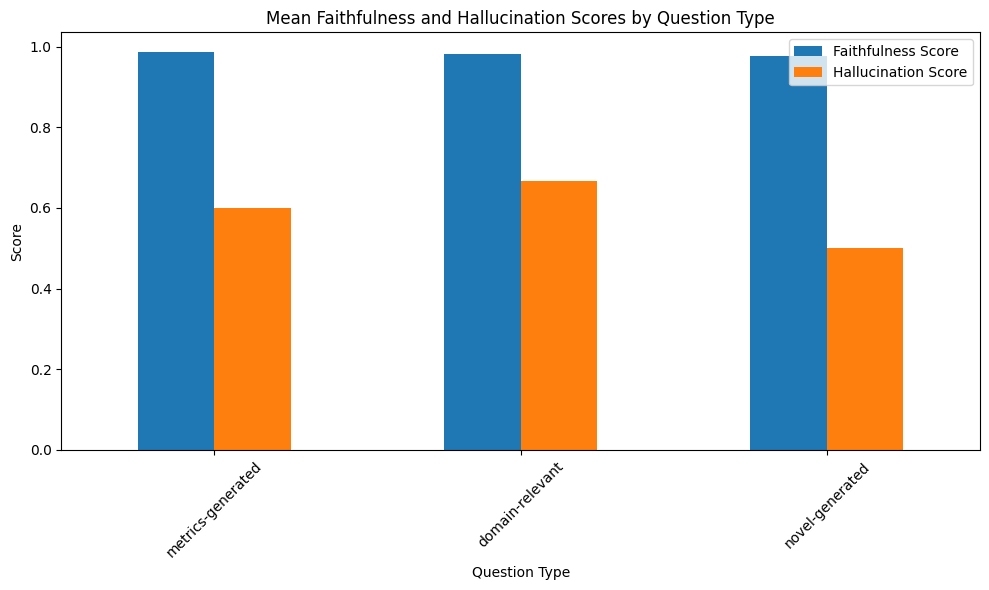

In [43]:
# Visualize mean scores
mean_scores.plot(kind='bar', figsize=(10, 6))
plt.title('Mean Faithfulness and Hallucination Scores by Question Type')
plt.ylabel('Score')
plt.xlabel('Question Type')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Refined Hallucination Analysis

Handling missing values for Hallucination Score (treating NaN as 0.0) and re-evaluating performance.  
**Note:** For Hallucination Score, a **lower** value indicates better performance (fewer hallucinations).

In [46]:
# Fill NaN values in 'Hallucination Score' with 0.0
df_merged['Hallucination Score'] = df_merged['Hallucination Score'].fillna(0.0)
print("Filled NaN values in 'Hallucination Score' with 0.0")


Filled NaN values in 'Hallucination Score' with 0.0


In [47]:
# Re-calculate mean scores with filled values
refined_mean_scores = df_merged.groupby('question_type')[['Faithfulness Score', 'Hallucination Score']].mean()
print("Refined Mean Scores by Question Type (Lower Hallucination is Better):")
print(refined_mean_scores)


Refined Mean Scores by Question Type (Lower Hallucination is Better):
                   Faithfulness Score  Hallucination Score
question_type                                             
domain-relevant              0.981337             0.083333
metrics-generated            0.986395             0.078947
novel-generated              0.976852             0.030303


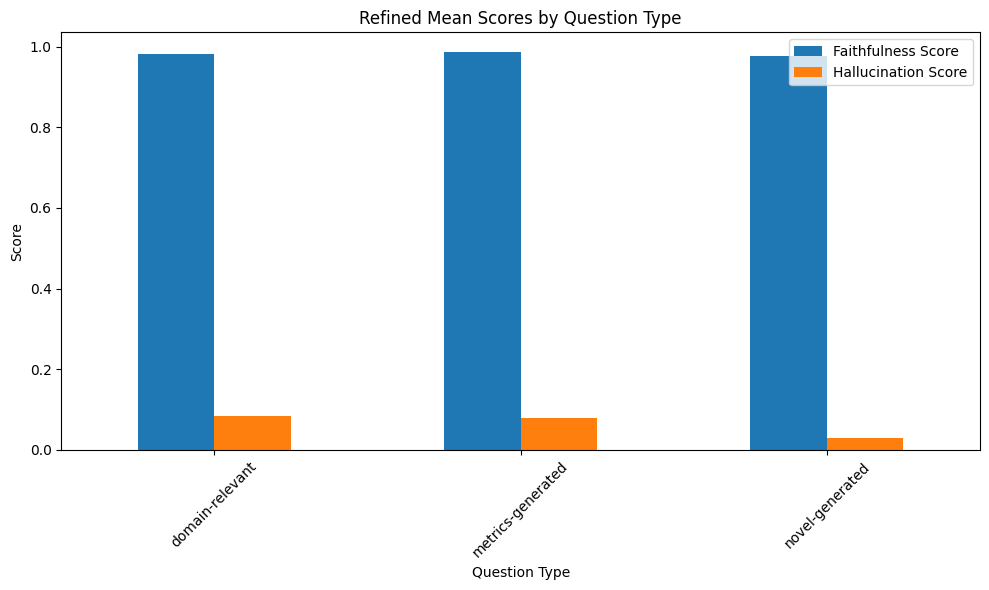

In [48]:
# Visualize refined scores
refined_mean_scores.plot(kind='bar', figsize=(10, 6))
plt.title('Refined Mean Scores by Question Type')
plt.ylabel('Score')
plt.xlabel('Question Type')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Question Type Definitions

Based on analysis of the dataset examples, the question types can be defined as follows:

- **metrics-generated**: Questions that ask for direct extraction of specific financial metrics or numbers from the documents.  
  *Example:* "What is the FY2018 capital expenditure amount..."

- **domain-relevant**: Questions that require applying financial domain knowledge or logical reasoning to the extracted information. These often ask for qualitative assessments based on quantitative data.  
  *Example:* "Is 3M a capital-intensive business based on FY2022 data?"

- **novel-generated**: Questions designed to test capabilities beyond standard extraction, often involving hypotheticals, exclusions, or synthesized insights not directly present as a single line item.  
  *Example:* "If we exclude the impact of M&A, which segment..."